# 05. Hypothesis: Asymmetric Cost Function

Проверка гипотезы: оптимизация threshold под асимметричную
функцию стоимости (FNR важнее FPR) улучшит OOS Recall
при приемлемой потере In-Domain Accuracy.

## Содержание
1. Setup
2. Постановка гипотезы
3. Метод
4. Эксперимент
5. Pareto-кривая
6. Выводы

## 1. Setup

In [2]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"
RUNS = TASK_DIR / "runs"

sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir: {RESULTS}")
print(f"Runs dir: {RUNS}")

import os
print(f"\nOMP_NUM_THREADS={os.environ.get('OMP_NUM_THREADS', 'not set')}")

Project root: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails
Results dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results
Runs dir: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/runs

OMP_NUM_THREADS=1


## 2. Постановка гипотезы

### Текущее поведение AutoIntent

Стандартный threshold в AutoIntent оптимизируется под **F1-score**,
который симметрично взвешивает False Negatives (FN) и False Positives (FP):

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

### Проблема для guardrail-сценария

В контексте guardrail для LLM-агента ошибки имеют **разную стоимость**:

| Ошибка | Описание | Последствие | Стоимость |
|--------|----------|-------------|----------|
| **FN** (False Negative) | OOS-запрос пропущен как in-scope | Агент пытается ответить на запрос вне компетенции → **неверный/опасный ответ** | **Высокая** |
| **FP** (False Positive) | In-scope запрос заблокирован как OOS | Агент отвечает "не могу помочь" → **безопасный fallback** | Низкая |

FN >> FP по стоимости, потому что:
- FN приводит к потенциально вредным действиям агента
- FP лишь снижает utility, но не создаёт риска

### Гипотеза

**Оптимизация threshold под асимметричную функцию стоимости:**

$$\text{Cost} = \alpha \cdot FNR + \beta \cdot FPR, \quad \alpha > \beta$$

где:
- $FNR = \frac{FN}{FN + TP}$ — доля пропущенных OOS (= 1 - OOS Recall)
- $FPR = \frac{FP}{FP + TN}$ — доля ложно заблокированных in-scope

**Ожидание:** при $\alpha > \beta$ threshold сдвинется влево (станет
более "параноидальным"), что даст:
- **Рост OOS Recall** (меньше FN)
- **Падение In-Domain Acc** (больше FP)
- **Общий выигрыш** для guardrail-сценария, если падение Acc приемлемо

## 3. Метод

### Функция оптимизации threshold

Перебираем threshold от 0 до 1 и выбираем тот, который минимизирует
взвешенную сумму FNR и FPR на validation set.

In [3]:
from shared.metrics import get_oos_scores_from_pipeline
from shared.data_utils import load_clinc150


def optimize_threshold(oos_scores_val, y_val, alpha, beta, n_thresholds=200):
    """
    Подбирает threshold минимизируя alpha*FNR + beta*FPR на val.
    
    Args:
        oos_scores_val: OOS-скоры на val (выше = более OOS)
        y_val: истинные метки (-1 = OOS, 0..N = in-scope)
        alpha: вес FNR (пропуск OOS)
        beta: вес FPR (ложная блокировка in-scope)
        n_thresholds: число точек для перебора
    
    Returns:
        best_t: оптимальный threshold
        best_cost: значение cost function
    """
    thresholds = np.linspace(0, 1, n_thresholds)
    best_t, best_cost = 0.5, np.inf
    
    y_true_oos = (np.array(y_val) == -1).astype(int)
    
    for t in thresholds:
        y_pred_oos = (oos_scores_val >= t).astype(int)
        
        tp = ((y_pred_oos == 1) & (y_true_oos == 1)).sum()
        fn = ((y_pred_oos == 0) & (y_true_oos == 1)).sum()
        fp = ((y_pred_oos == 1) & (y_true_oos == 0)).sum()
        tn = ((y_pred_oos == 0) & (y_true_oos == 0)).sum()
        
        fnr = fn / (fn + tp + 1e-9)
        fpr = fp / (fp + tn + 1e-9)
        cost = alpha * fnr + beta * fpr
        
        if cost < best_cost:
            best_cost, best_t = cost, t
    
    return best_t, best_cost


def evaluate_threshold(oos_scores, y_true, threshold):
    """
    Оценивает метрики при заданном threshold.
    
    Returns:
        dict с метриками: oos_recall, in_domain_acc, f1_oos, fnr, fpr
    """
    y_true = np.array(y_true)
    y_true_oos = (y_true == -1).astype(int)
    y_pred_oos = (oos_scores >= threshold).astype(int)
    
    tp = ((y_pred_oos == 1) & (y_true_oos == 1)).sum()
    fn = ((y_pred_oos == 0) & (y_true_oos == 1)).sum()
    fp = ((y_pred_oos == 1) & (y_true_oos == 0)).sum()
    tn = ((y_pred_oos == 0) & (y_true_oos == 0)).sum()
    
    oos_recall = tp / (tp + fn + 1e-9)
    fnr = fn / (fn + tp + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    in_domain_acc = tn / (tn + fp + 1e-9)  # = 1 - FPR на in-scope
    
    precision = tp / (tp + fp + 1e-9)
    f1_oos = 2 * precision * oos_recall / (precision + oos_recall + 1e-9)
    
    return {
        "oos_recall": oos_recall,
        "in_domain_acc": in_domain_acc,
        "f1_oos": f1_oos,
        "fnr": fnr,
        "fpr": fpr,
    }


print("Functions defined.")

Functions defined.


### Тестируемые соотношения α:β

| Соотношение | Интерпретация |
|-------------|---------------|
| 1:1 | Baseline (эквивалент F1-оптимизации) |
| 2:1 | Умеренный акцент на FNR |
| 5:1 | Сильный акцент на FNR |
| 10:1 | Очень сильный акцент на FNR |

## 4. Эксперимент

Запускаем оптимизацию threshold для 20-shot моделей (3 seeds)
с разными соотношениями α:β.

In [4]:
from autointent import Pipeline

# Load validation and test data
val_data = load_clinc150("validation", PROCESSED)
test_data = load_clinc150("test", PROCESSED)

val_texts = val_data["texts"]
val_labels = np.array(val_data["labels"])
test_texts = test_data["texts"]
test_labels = np.array(test_data["labels"])

print(f"Val samples: {len(val_texts)} (OOS: {(val_labels == -1).sum()})")
print(f"Test samples: {len(test_texts)} (OOS: {(test_labels == -1).sum()})")

Val samples: 3097 (OOS: 100)
Test samples: 5498 (OOS: 1000)


In [5]:
# Experiment configuration
SEEDS = [42, 123, 456]
N_SHOTS = 20
ALPHA_BETA_RATIOS = [
    (1, 1, "1:1 (F1)"),
    (2, 1, "2:1"),
    (5, 1, "5:1"),
    (10, 1, "10:1"),
]

# Collect results
all_results = []

for seed in SEEDS:
    model_dir = RUNS / f"autointent_classic-light_{N_SHOTS}shot_seed{seed}"
    
    if not model_dir.exists():
        print(f"Model not found: {model_dir}")
        continue
    
    print(f"\nProcessing seed={seed}...")
    
    # Load pipeline
    pipeline = Pipeline.load(model_dir)
    
    # Get OOS scores
    print("  Getting OOS scores on val...")
    oos_scores_val = get_oos_scores_from_pipeline(pipeline, val_texts)
    
    print("  Getting OOS scores on test...")
    oos_scores_test = get_oos_scores_from_pipeline(pipeline, test_texts)
    
    # Test each alpha:beta ratio
    for alpha, beta, label in ALPHA_BETA_RATIOS:
        # Optimize threshold on val
        best_t, best_cost = optimize_threshold(
            oos_scores_val, val_labels, alpha, beta
        )
        
        # Evaluate on test
        metrics = evaluate_threshold(oos_scores_test, test_labels, best_t)
        
        result = {
            "seed": seed,
            "alpha_beta": label,
            "alpha": alpha,
            "beta": beta,
            "threshold": best_t,
            "val_cost": best_cost,
            **metrics,
        }
        all_results.append(result)
        
        print(f"    {label}: t={best_t:.3f}, Recall={metrics['oos_recall']:.3f}, "
              f"Acc={metrics['in_domain_acc']:.3f}, F1={metrics['f1_oos']:.3f}")

# Create DataFrame
results_df = pd.DataFrame(all_results)
print(f"\nTotal results: {len(results_df)}")


Processing seed=42...
  Getting OOS scores on val...
  Getting OOS scores on test...
    1:1 (F1): t=0.804, Recall=0.905, Acc=0.927, F1=0.811
    2:1: t=0.804, Recall=0.905, Acc=0.927, F1=0.811
    5:1: t=0.628, Recall=0.980, Acc=0.748, F1=0.629
    10:1: t=0.558, Recall=0.988, Acc=0.656, F1=0.559

Processing seed=123...
  Getting OOS scores on val...
  Getting OOS scores on test...
    1:1 (F1): t=0.819, Recall=0.891, Acc=0.940, F1=0.825
    2:1: t=0.704, Recall=0.964, Acc=0.838, F1=0.716
    5:1: t=0.688, Recall=0.967, Acc=0.819, F1=0.695
    10:1: t=0.688, Recall=0.967, Acc=0.819, F1=0.695

Processing seed=456...
  Getting OOS scores on val...
  Getting OOS scores on test...
    1:1 (F1): t=0.814, Recall=0.901, Acc=0.934, F1=0.820
    2:1: t=0.759, Recall=0.941, Acc=0.885, F1=0.765
    5:1: t=0.724, Recall=0.961, Acc=0.850, F1=0.729
    10:1: t=0.663, Recall=0.973, Acc=0.785, F1=0.662

Total results: 12


In [6]:
# Aggregate by alpha_beta (mean ± std across seeds)
agg_results = results_df.groupby("alpha_beta").agg({
    "threshold": ["mean", "std"],
    "oos_recall": ["mean", "std"],
    "in_domain_acc": ["mean", "std"],
    "f1_oos": ["mean", "std"],
    "fnr": ["mean", "std"],
    "fpr": ["mean", "std"],
}).reset_index()

# Flatten column names
agg_results.columns = ["_".join(col).strip("_") for col in agg_results.columns]

# Sort by alpha (extract from label)
order = ["1:1 (F1)", "2:1", "5:1", "10:1"]
agg_results["sort_key"] = agg_results["alpha_beta"].apply(lambda x: order.index(x))
agg_results = agg_results.sort_values("sort_key").drop(columns=["sort_key"])

# Display formatted table
print("Results by α:β ratio (mean ± std across 3 seeds)")
print("=" * 90)

display_df = pd.DataFrame({
    "α:β": agg_results["alpha_beta"],
    "Threshold": agg_results.apply(
        lambda r: f"{r['threshold_mean']:.3f} ± {r['threshold_std']:.3f}", axis=1),
    "OOS Recall": agg_results.apply(
        lambda r: f"{r['oos_recall_mean']:.3f} ± {r['oos_recall_std']:.3f}", axis=1),
    "In-Domain Acc": agg_results.apply(
        lambda r: f"{r['in_domain_acc_mean']:.3f} ± {r['in_domain_acc_std']:.3f}", axis=1),
    "F1 OOS": agg_results.apply(
        lambda r: f"{r['f1_oos_mean']:.3f} ± {r['f1_oos_std']:.3f}", axis=1),
    "FPR": agg_results.apply(
        lambda r: f"{r['fpr_mean']:.3f} ± {r['fpr_std']:.3f}", axis=1),
})

display(display_df)

Results by α:β ratio (mean ± std across 3 seeds)


,α:β,Threshold,OOS Recall,In-Domain Acc,F1 OOS,FPR
1,1:1 (F1),0.812 ± 0.008,0.899 ± 0.007,0.934 ± 0.007,0.818 ± 0.007,0.066 ± 0.007
2,2:1,0.755 ± 0.050,0.937 ± 0.030,0.883 ± 0.045,0.764 ± 0.047,0.117 ± 0.045
3,5:1,0.680 ± 0.048,0.969 ± 0.010,0.806 ± 0.052,0.685 ± 0.051,0.194 ± 0.052
0,10:1,0.637 ± 0.069,0.976 ± 0.011,0.753 ± 0.086,0.639 ± 0.071,0.247 ± 0.086


In [7]:
# Save results to JSON
results_json = {
    "experiment": "asymmetric_cost_threshold",
    "n_shots": N_SHOTS,
    "seeds": SEEDS,
    "raw_results": all_results,
    "aggregated": agg_results.to_dict(orient="records"),
}

output_file = RESULTS / "hypothesis_asymmetric_cost.json"
output_file.write_text(json.dumps(results_json, indent=2, ensure_ascii=False))
print(f"Saved to {output_file}")

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/hypothesis_asymmetric_cost.json


## 5. Pareto-кривая

Визуализация trade-off между FPR и OOS Recall при разных α:β.

In [8]:
# Load baseline for comparison
metrics_all = json.loads((RESULTS / "metrics.json").read_text())
baseline_e5 = [r for r in metrics_all 
               if r["model_name"] == "cosine_e5large_threshold" 
               and r.get("n_shots") == N_SHOTS]

if baseline_e5:
    baseline_recall = np.mean([r["oos_recall"] for r in baseline_e5])
    baseline_acc = np.mean([r["in_domain_acc"] for r in baseline_e5])
    baseline_fpr = 1 - baseline_acc
    print(f"Baseline (E5-Large threshold): Recall={baseline_recall:.3f}, FPR={baseline_fpr:.3f}")
else:
    baseline_recall, baseline_fpr = None, None
    print("Baseline not found")

Baseline (E5-Large threshold): Recall=0.551, FPR=0.119


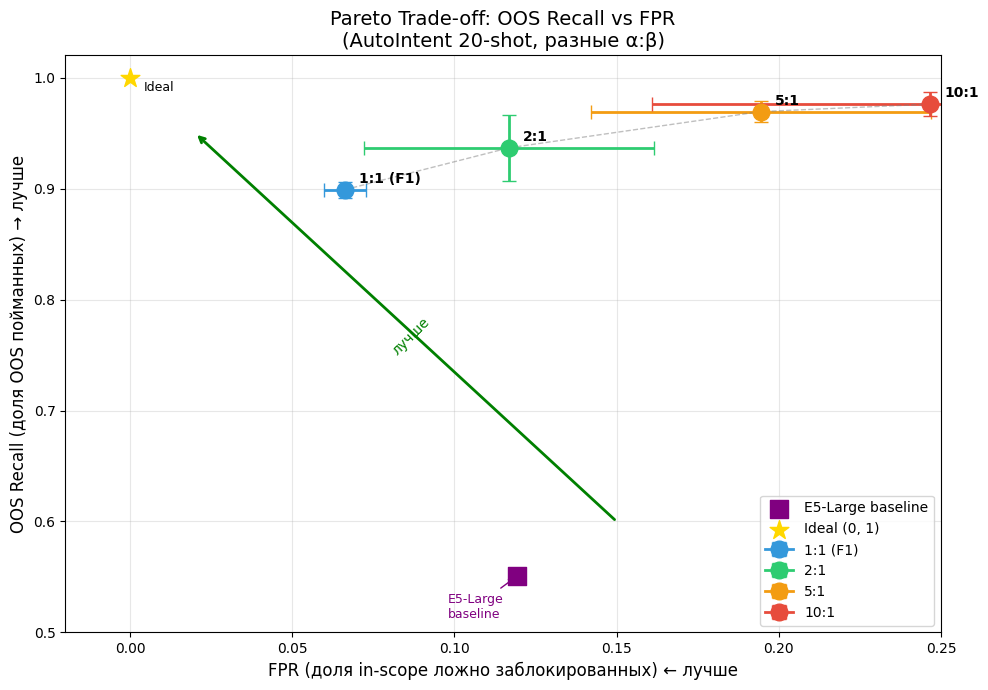

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/hypothesis_asymmetric_cost_pareto.png


In [9]:
# Plot Pareto curve
fig, ax = plt.subplots(figsize=(10, 7))

# Colors for different ratios
colors = {
    "1:1 (F1)": "#3498db",
    "2:1": "#2ecc71",
    "5:1": "#f39c12",
    "10:1": "#e74c3c",
}

# Plot each ratio with error bars
for _, row in agg_results.iterrows():
    label = row["alpha_beta"]
    ax.errorbar(
        row["fpr_mean"], row["oos_recall_mean"],
        xerr=row["fpr_std"], yerr=row["oos_recall_std"],
        marker="o", markersize=12, capsize=5,
        color=colors[label], label=label,
        linewidth=2, elinewidth=2,
    )
    
    # Add text label
    ax.annotate(
        label,
        (row["fpr_mean"], row["oos_recall_mean"]),
        xytext=(10, 5), textcoords="offset points",
        fontsize=10, fontweight="bold",
    )

# Connect points with line (Pareto frontier approximation)
sorted_agg = agg_results.sort_values("fpr_mean")
ax.plot(
    sorted_agg["fpr_mean"], sorted_agg["oos_recall_mean"],
    "--", color="gray", alpha=0.5, linewidth=1,
)

# Add baseline point
if baseline_recall is not None:
    ax.scatter(
        baseline_fpr, baseline_recall,
        marker="s", s=150, color="purple", zorder=10,
        label="E5-Large baseline",
    )
    ax.annotate(
        "E5-Large\nbaseline",
        (baseline_fpr, baseline_recall),
        xytext=(-50, -30), textcoords="offset points",
        fontsize=9, color="purple",
        arrowprops=dict(arrowstyle="->", color="purple", lw=1),
    )

# Ideal point (0, 1)
ax.scatter(0, 1, marker="*", s=200, color="gold", zorder=10, label="Ideal (0, 1)")
ax.annotate("Ideal", (0, 1), xytext=(10, -10), textcoords="offset points", fontsize=9)

ax.set_xlabel("FPR (доля in-scope ложно заблокированных) ← лучше", fontsize=12)
ax.set_ylabel("OOS Recall (доля OOS пойманных) → лучше", fontsize=12)
ax.set_title("Pareto Trade-off: OOS Recall vs FPR\n(AutoIntent 20-shot, разные α:β)", fontsize=14)
ax.set_xlim(-0.02, 0.25)
ax.set_ylim(0.5, 1.02)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# Add arrow indicating "better" direction
ax.annotate(
    "", xy=(0.02, 0.95), xytext=(0.15, 0.6),
    arrowprops=dict(arrowstyle="->", color="green", lw=2),
)
ax.text(0.08, 0.75, "лучше", fontsize=10, color="green", rotation=45)

plt.tight_layout()
plt.savefig(RESULTS / "hypothesis_asymmetric_cost_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS / 'hypothesis_asymmetric_cost_pareto.png'}")

## 6. Выводы

**Гипотеза технически подтверждена, но практически неинтересна.** Асимметричная cost function действительно смещает threshold и увеличивает OOS Recall — механизм работает как ожидалось. При переходе от 1:1 к 10:1 Recall растёт с 0.899 до 0.976, что демонстрирует управляемость trade-off через коэффициенты α и β.

**Проблема 1 — невыгодный trade-off.** F1-оптимизированный baseline (1:1) уже достигает Recall=0.899 при FPR=0.066. Переход к 2:1 даёт лишь +3.8 п.п. Recall, но удваивает FPR (0.066→0.117) и теряет 5.1 п.п. In-Domain Acc. При 5:1 и 10:1 каждый пятый-четвёртый легитимный запрос блокируется — неприемлемо для production guardrail. Marginal utility дополнительного Recall падает экспоненциально, тогда как cost в виде FPR растёт линейно.

**Проблема 2 — нестабильность при 2:1.** Std для In-Domain Acc = 0.045: поведение сильно зависит от конкретной обучающей выборки, а не от коэффициентов. Seed=42 вообще не реагирует на 2:1 (threshold не сдвигается), тогда как seeds 123 и 456 дают существенное смещение. Это делает 2:1 ненадёжной operating point — результат непредсказуем при переобучении модели.

**Положительный результат — AutoIntent Pareto-доминирует над бейзлайном.** При стандартном F1 threshold AutoIntent (1:1) одновременно лучше cosine_e5large_threshold и по Recall (0.899 vs 0.551) и по FPR (0.066 vs 0.119). Это подтверждает, что AutoML-оптимизация даёт качественно лучшую рабочую точку, чем ручная калибровка threshold на том же embedder'е.

**Вывод.** Асимметричная cost function — это настраиваемый knob для practitioners с конкретными требованиями к Recall, но не самостоятельное улучшение пайплайна. Гипотеза опровергнута в части "улучшит без критической потери In-Domain Acc": при любом α > 1 потери существенны и нестабильны. Для задачи OOS-детекции на CLINC150 стандартная F1-оптимизация AutoIntent уже обеспечивает хороший guardrail-баланс — дальнейшее смещение threshold в сторону Recall экономически нецелесообразно.